In [1]:
import pandas as pd
from pandas import read_csv

##### Loading Data:

In [2]:
path =r"haberman.csv"
data = read_csv(path, header=None)

In [3]:
data.shape

(306, 4)

In [4]:
data.head(4)

,0,1,2,3
0,30,64,1,1
1,30,62,3,1
2,30,65,0,1
3,31,59,2,1


##### Summary Statistics:

In [5]:
data.describe()

,0,1,2,3
count,306.000000,306.000000,306.000000,306.000000
mean,52.457516,62.852941,4.026144,1.264706
std,10.803452,3.249405,7.189654,0.441899
min,30.000000,58.000000,0.000000,1.000000
25%,44.000000,60.000000,0.000000,1.000000
50%,52.000000,63.000000,1.000000,1.000000
75%,60.750000,65.750000,4.000000,2.000000
max,83.000000,69.000000,52.000000,2.000000


array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>]],
      dtype=object)

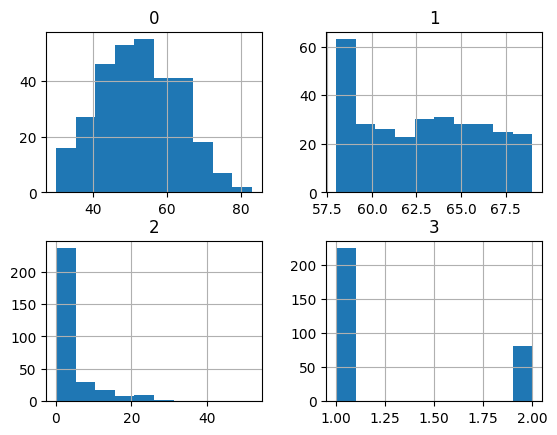

In [6]:
data.hist()

In [7]:
from collections import Counter

In [8]:
columns = ['Age', 'Year', 'Nodes', 'Class']

# Loading the dataset with Columns Names
data_names = read_csv(path, header=None, names=columns)

# Calculating the targets:
targets = data_names['Class'].values

counter = Counter(targets);

for key, value in counter.items():
    percentage = value / len(targets) *100
    print(f"Class {key}: {value} ({percentage:.2f}%)")

Class 1: 225 (73.53%)
Class 2: 81 (26.47%)


In [9]:
a=0
b=0
for i in    targets:
    if i==1:
        a+=1
    else:
        b+=1
print(a)
print(b)
print(counter)
print('\n')
print(targets)

225
81
Counter({np.int64(1): 225, np.int64(2): 81})


[1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 2 1 1
 1 1 1 1 1 1 2 2 2 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 2 2 2 2 1 1 1 1 1 1 1 2
 2 2 1 1 1 1 2 2 2 1 1 1 1 1 1 2 2 2 2 1 1 1 2 2 2 1 1 1 1 1 1 1 1 2 2 2 1
 1 1 1 2 2 1 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 1 1 1 2 2 1 1 1 1 2 2 2 2 1 1
 1 1 1 1 1 1 1 1 2 2 2 2 2 2 1 1 1 1 1 2 2 2 2 1 1 1 1 1 1 1 1 1 2 2 1 1 1
 1 1 1 1 1 2 2 1 1 1 1 1 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1
 1 2 2 1 1 1 1 2 2 2 1 1 1 1 1 1 2 2 2 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 2
 2 2 2 1 1 1 1 1 1 2 2 1 1 1 2 2 1 1 1 1 1 1 2 1 1 1 2 2 1 1 1 1 1 1 2 1 1
 1 1 1 2 1 1 1 1 2 2]


In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


# Preparing the X (inputs) and Y (targets)
X =data_names.values[:,:-1]
Y =data_names.values[:, -1]

# Preprocessing :
X = X.astype('float32') # This is important for the model to work properly cause the model will not accept other data types.
Y = LabelEncoder().fit_transform(Y) # This is important for the model to work properly cause the model will not accept other data types.

# Splitting the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=3, stratify=Y)

In [11]:
print(type(X))
X[1:10]

<class 'numpy.ndarray'>


array([[30., 62.,  3.],
       [30., 65.,  0.],
       [31., 59.,  2.],
       [31., 65.,  4.],
       [33., 58., 10.],
       [33., 60.,  0.],
       [34., 59.,  0.],
       [34., 66.,  9.],
       [34., 58., 30.]], dtype=float32)

In [12]:
print(type(Y))
Y[1:10]

<class 'numpy.ndarray'>


array([0, 0, 0, 0, 0, 0, 1, 1, 0])

##### Building && Preparing Deep Learning Model:

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


# Number of features in the dataset
n_features = X_train.shape[1]

# Building the model 
model = Sequential()
model.add(Dense(10, activation='relu', input_shape=(n_features,)))
model.add(Dense(1, activation='sigmoid'))

I0000 00:00:1787120360.950720   11242 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787120360.951353   11242 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787120361.290429   11242 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787120362.977260   11242 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [14]:
from tensorflow.keras import Input


model = Sequential([
    Input(shape=(n_features,)),    
    Dense(10, activation='relu',),
    Dense(1, activation='sigmoid')
])

##### Set the Model Configuration:

In [15]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

##### Train The ML Model:

In [16]:
history =model.fit(X_train, Y_train, epochs=200, batch_size=20, validation_split=0.2, validation_data=(X_test, Y_test), verbose=1)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2664 - loss: 14.1685 - val_accuracy: 0.2581 - val_loss: 13.4070
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2664 - loss: 12.4649 - val_accuracy: 0.2581 - val_loss: 11.7294
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2664 - loss: 10.8197 - val_accuracy: 0.2581 - val_loss: 10.0518
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2664 - loss: 9.1806 - val_accuracy: 0.2581 - val_loss: 8.4565
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2705 - loss: 7.5890 - val_accuracy: 0.2581 - val_loss: 6.9223
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2664 - loss: 6.0439 - val_accuracy: 0.2581 - val_loss: 5.4209
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2705 - loss: 4.5707 - val_accuracy: 0.2097 - val_loss: 3.9893
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2787 - loss: 3.1909 - val_accuracy: 0.2

In [17]:
from sklearn.metrics import accuracy_score

Y_pred = (model.predict(X_test) > 0.5).astype(int)

score = accuracy_score(Y_test, Y_pred)

print(f"Accuracy: {score:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Accuracy: 0.81%


##### Learning Curves : Loss

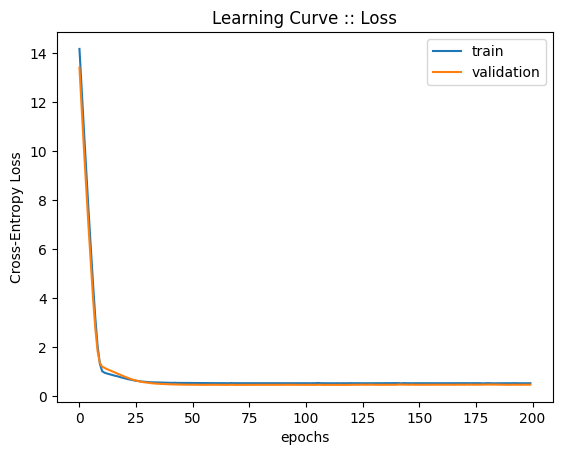

In [18]:
import matplotlib.pyplot as plt

plt.title("Learning Curve :: Loss")
plt.xlabel("epochs")
plt.ylabel("Cross-Entropy Loss")
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.legend()
plt.show()

##### Learning Curves : Accuracy

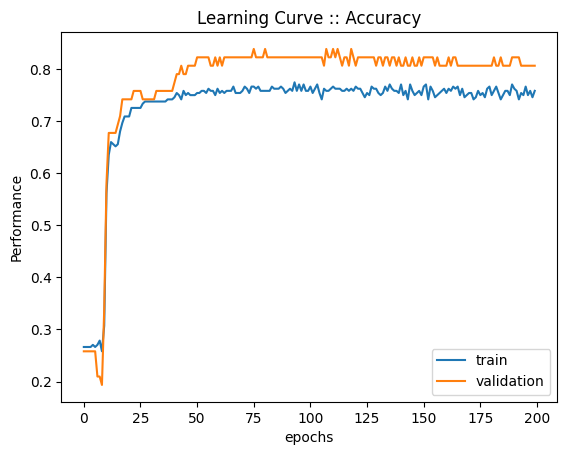

In [19]:
plt.title("Learning Curve :: Accuracy")
plt.xlabel("epochs")
plt.ylabel("Performance")
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.show()